# Execution algorithms and the cost of not finishing

Recipe 01/02 measures VWAP and TWAP as benchmarks. This one trades to them.
The order is 20,000 shares to buy in a name that shows a few hundred at the
touch, which is the situation every execution desk is actually in: the
liquidity you need does not exist at the moment you decide you need it.

The mistake this recipe is built to prevent is measuring execution by average
price alone. An algorithm can beat any benchmark by not trading, and the
shares it failed to buy are a position you do not have in a market that moved
without you. Perold's implementation shortfall counts both halves, and a
replay produces the numbers for it directly: fills are what the book granted,
and the unfilled remainder is in the same tables.

## Terms used here

| term                    | meaning |
| ----------------------- | --- |
| parent order            | the full quantity a desk has been asked to trade |
| slice                   | one child order sent as part of working the parent |
| arrival price           | the mid at the instant the decision was made; the honest benchmark |
| TWAP                    | a schedule that spreads slices evenly over time |
| VWAP                    | a schedule that spreads slices in proportion to expected volume |
| POV                     | participation of volume: trade a fixed fraction of what prints |
| implementation shortfall| cost against the arrival price, including the shares never bought |
| opportunity cost        | what the unfilled remainder would have cost to buy at the end |

New to any of these? [GLOSSARY.md](../../GLOSSARY.md) defines them at more
length, along with every other term the cookbook uses.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt
import pandas as pd

import h5i_db
from h5i_db import backtest
from h5i_db.quant import costs
import cookbook_utils as cu

SYMBOL = "ACME"
PARENT = 20_000.0
SLICES = 40

## 1. Two sessions, and only one of them is tradeable

The tape carries two days. The first is history, used to estimate the volume
profile a VWAP schedule needs. The second is the day the order is worked.

Splitting them is not bookkeeping. A VWAP schedule fitted to the volume of the
day you are trading is not a schedule, it is a forecast you already know the
answer to, and it will beat every benchmark in a backtest and none in
production.

In [2]:
quotes = cu.make_quotes(symbols=[SYMBOL], days=2, quotes_per_day=2_500, seed=17)
tape = cu.make_equity_tape(quotes, action="set", print_every=2, print_size=300.0)
for name, table in tape.items():
    print(f"{name}: {table.num_rows:,} rows x {table.num_columns} columns")

prints = tape["trades"].to_pandas()
prints["session"] = prints["ts_init"].dt.date
history, live = sorted(prints["session"].unique())
print(f"\nprofile session {history}, execution session {live}")
tape["trades"].to_pandas().head(3)

instruments: 1 rows x 10 columns
book_deltas: 20,017 rows x 11 columns
trades: 2,630 rows x 9 columns

profile session 2026-06-01, execution session 2026-06-02


,ts_init,ts_event,instrument_id,outcome,price,size,aggressor,trade_id,source_vendor
0,2026-06-01 13:30:00.756179,2026-06-01 13:30:00.756179,ACME,0,344.25,300.0,buy,ACME-0,cookbook-tape
1,2026-06-01 13:30:05.811813,2026-06-01 13:30:05.811813,ACME,0,344.22,300.0,sell,ACME-2,cookbook-tape
2,2026-06-01 13:30:20.581353,2026-06-01 13:30:20.581353,ACME,0,344.15,300.0,buy,ACME-4,cookbook-tape


In [3]:
db = h5i_db.Database(cu.fresh_db("04_execution_algorithms"), create=True)
for name, table in tape.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="two-session tape")
db.snapshot("tape-v1", tables=list(tape), note="Market data every algorithm reads")

book = tape["book_deltas"].to_pandas()
touch = (
    book[book["action"].isin(["set", "snapshot"])]
    .pivot_table(index="ts_init", columns="side", values="price", aggfunc="last")
    .ffill()
    .dropna()
)
touch["mid"] = (touch["buy"] + touch["sell"]) / 2
session_touch = touch[touch.index.date == live]
ARRIVAL = session_touch.index[0]
arrival_mid = float(session_touch["mid"].iloc[0])
final_mid = float(session_touch["mid"].iloc[-1])
print(f"arrival {ARRIVAL}  mid {arrival_mid:.4f}")
print(f"close   {session_touch.index[-1]}  mid {final_mid:.4f}")
print(f"the market moved {10_000 * (final_mid / arrival_mid - 1):.1f} bp while the order was worked")

arrival 2026-06-02 13:30:01.907473  mid 344.3400
close   2026-06-02 19:59:45.193775  mid 343.9150
the market moved -12.3 bp while the order was worked


## 2. Three schedules and one reaction

TWAP and VWAP are *schedules*: the whole plan is known before the session
starts, so both are ordinary signal tables. POV is a *reaction* to volume that
has not printed yet, so it has to be a callback. Choosing the simplest
boundary that expresses the algorithm is the rule; POV is where the simple
boundary stops being enough.

In [4]:
grid = pd.date_range(
    session_touch.index[0], session_touch.index[-1], periods=SLICES + 1, inclusive="left"
)
volume_profile = (
    prints[prints["session"] == history]
    .assign(bucket=lambda frame: pd.cut(
        frame["ts_init"],
        bins=pd.date_range(
            frame["ts_init"].min(), frame["ts_init"].max(), periods=SLICES + 1
        ),
        labels=False,
        include_lowest=True,
    ))
    .groupby("bucket")["size"]
    .sum()
    .reindex(range(SLICES), fill_value=0.0)
)
weights = volume_profile / volume_profile.sum()
schedule = pd.DataFrame(
    {
        "slice_ts": grid,
        "twap": PARENT / SLICES,
        "vwap": (weights.to_numpy() * PARENT).round(),
    }
)
print(f"TWAP slice {schedule['twap'].iloc[0]:,.0f} shares")
print(f"VWAP slices {schedule['vwap'].min():,.0f} to {schedule['vwap'].max():,.0f} shares")
schedule.head()

TWAP slice 500 shares
VWAP slices 108 to 1,531 shares


,slice_ts,twap,vwap
0,2026-06-02 13:30:01.907473000,500.0,1500.0
1,2026-06-02 13:39:46.489630550,500.0,1531.0
2,2026-06-02 13:49:31.071788100,500.0,1485.0
3,2026-06-02 13:59:15.653945650,500.0,1191.0
4,2026-06-02 14:09:00.236103200,500.0,1036.0


In [5]:
backtest.create_signal_table(db)
for algorithm in ("twap", "vwap"):
    rows = [
        {
            "ts": row.slice_ts.floor("us").to_pydatetime() + dt.timedelta(microseconds=1),
            "instrument_id": SYMBOL,
            "side": "buy",
            "quantity": float(getattr(row, algorithm)),
            "kind": "market",
            "tag": algorithm,
        }
        for row in schedule.itertuples()
        if getattr(row, algorithm) > 0
    ]
    table = backtest.signal_table(rows)
    db.create_table(f"signals_{algorithm}", table.schema, time_column="ts")
    db.append(f"signals_{algorithm}", table, note=f"{algorithm} schedule")

immediate = backtest.signal_table(
    [
        {
            "ts": ARRIVAL.floor("us").to_pydatetime() + dt.timedelta(microseconds=1),
            "instrument_id": SYMBOL,
            "side": "buy",
            "quantity": PARENT,
            "kind": "market",
            "tag": "immediate",
        }
    ]
)
db.create_table("signals_immediate", immediate.schema, time_column="ts")
db.append("signals_immediate", immediate, note="the whole parent, at once")
db.snapshot("plans-v1", tables=["signals_twap", "signals_vwap", "signals_immediate"])
db.tables()

['book_deltas',
 'instruments',
 'signals',
 'signals_immediate',
 'signals_twap',
 'signals_vwap',
 'trades']

In [6]:
class ParticipateOfVolume(backtest.EventStrategy):
    """Take a fixed share of every print until the parent is done."""

    def __init__(self, parent=PARENT, participation=0.25, start=None):
        self.remaining = parent
        self.participation = participation
        self.start = start
        self.sent = 0

    def on_event(self, context, event):
        if event.get("kind") != "trade" or self.remaining <= 0:
            return None
        if self.start is not None and event["ts_init"] < self.start:
            return None
        quantity = min(self.remaining, round(event["size"] * self.participation))
        if quantity <= 0:
            return None
        self.sent += 1
        return {
            "action": "submit",
            "client_order_id": f"pov-{self.sent}",
            "instrument_id": SYMBOL,
            "side": "buy",
            "quantity": float(quantity),
            "tag": "pov",
        }

    def on_fill(self, context, event):
        self.remaining -= event["quantity"]
        return None

## 3. Run all four

Same book, same fees, same pin. The only thing that differs is when the shares
were asked for.

In [7]:
CASH = 10_000_000.0
COMMON = dict(
    execution=backtest.ExecutionConfig(fee_kind="proportional", fee_rate=0.0002),
    risk=backtest.RiskConfig(max_order_quantity=PARENT),
    output=backtest.OutputConfig(equity_interval_nanos=300_000_000_000),
)


def run_schedule(run_id, signals):
    return backtest.execute(
        db,
        backtest.BacktestConfig(
            run_id=run_id,
            portfolio=backtest.PortfolioConfig(starting_cash=CASH),
            data=backtest.DataConfig(signals=signals, snapshot="tape-v1"),
            **COMMON,
        ),
    )


def run_reaction(run_id, strategy):
    return backtest.run_strategy(
        db,
        run_id,
        strategy,
        strategy_id="cookbook.ParticipateOfVolume:v1",
        starting_cash=CASH,
        data=backtest.DataConfig(snapshot="tape-v1"),
        **COMMON,
    )


results = {
    "immediate": run_schedule("algo-immediate", "signals_immediate"),
    "twap": run_schedule("algo-twap", "signals_twap"),
    "vwap": run_schedule("algo-vwap", "signals_vwap"),
    "pov": run_reaction("algo-pov", ParticipateOfVolume(start=int(ARRIVAL.value) + 1_000)),
}
for label, result in results.items():
    print(f"{label:<10} orders {result['orders']:>4}  fills {result['fills']:>4}")

immediate  orders    1  fills    1
twap       orders   40  fills   40
vwap       orders   40  fills   40
pov        orders  267  fills  267


## 4. Implementation shortfall, both halves

`quant.costs` measures the executed half: each fill against the arrival mid,
weighted by size, which is what the desk actually paid per share. The half
that no cost model reports is the remainder, and it is priced here at the
closing mid -- the price you would have had to pay to finish.

In [8]:
def shortfall(result) -> dict:
    fills = result.fills.to_pandas()
    filled = float(fills["quantity"].sum())
    samples = [
        costs.SlippageSample(
            direction=1,
            fill_price=float(row.price),
            reference_price=arrival_mid,
            quantity=float(row.quantity),
        )
        for row in fills.itertuples()
    ]
    execution_cost = costs.implementation_shortfall(samples) * filled if samples else 0.0
    unfilled = PARENT - filled
    opportunity_cost = unfilled * (final_mid - arrival_mid)
    return {
        "filled": filled,
        "completion": filled / PARENT,
        "avg price": float((fills["price"] * fills["quantity"]).sum() / filled),
        "execution cost ($)": execution_cost,
        "opportunity cost ($)": opportunity_cost,
        "total shortfall ($)": execution_cost + opportunity_cost,
        "shortfall (bp of parent)": 10_000
        * (execution_cost + opportunity_cost)
        / (PARENT * arrival_mid),
    }


report = pd.DataFrame({label: shortfall(result) for label, result in results.items()}).T
report.round(3)

,filled,completion,avg price,execution cost ($),opportunity cost ($),total shortfall ($),shortfall (bp of parent)
immediate,500.0,0.025,344.390,25.00,-8287.50,-8262.50,-11.998
twap,12100.0,0.605,344.067,-3299.00,-3357.50,-6656.50,-9.666
vwap,10334.0,0.517,344.140,-2064.38,-4108.05,-6172.43,-8.963
pov,20000.0,1.000,344.569,4586.75,-0.00,4586.75,6.660


Costs are positive when the desk paid more than the arrival mid, so a negative
entry is a session that went the buyer's way.

Read the two cost columns against each other. Taking the whole parent at once
consumes the displayed size and stops, so its execution cost is trivial and
essentially all of its shortfall is a position it never got. POV is the only
algorithm that finishes, so it has no opportunity cost at all and carries the
entire cost in the price it paid.

The mid drifted down through this session, which rewards a buyer for being
slow, and the ranking says so. That is the finding: on one session the ranking
measures the drift, not the algorithm. Execution research averages shortfall
over hundreds of parent orders for exactly this reason, and a single-day
comparison should be read as a demonstration of the accounting rather than as
evidence about the algorithms.

What does generalize is the shape of the table. An execution report quoting
only average price against VWAP is unfalsifiable: the algorithm with the worst
average price may have been the only one that finished.

In [9]:
assert report.loc["immediate", "completion"] < 0.2, "the fixture stopped being illiquid"
assert report.loc["pov", "completion"] > report.loc["immediate", "completion"]
assert abs(report.loc["pov", "opportunity cost ($)"]) < 1e-6, "a finished order has no remainder"
print(f"lowest total shortfall  {report['total shortfall ($)'].idxmin()}")
print(f"highest total shortfall {report['total shortfall ($)'].idxmax()}")
print(f"completion range        {report['completion'].min():.1%} to {report['completion'].max():.1%}")

lowest total shortfall  immediate
highest total shortfall pov
completion range        2.5% to 100.0%


## 5. The participation curves

The shape of the execution is the algorithm. Plotting cumulative shares makes
the difference between a schedule and a reaction obvious: TWAP is a straight
line by construction, VWAP bends toward the busy parts of yesterday, and POV
only moves when the market does.

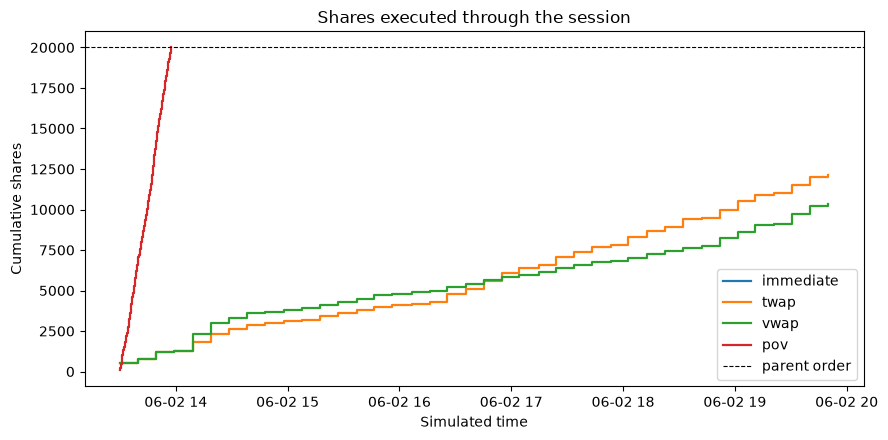

In [10]:
fig, ax = plt.subplots(figsize=(9, 4.5))
for label, result in results.items():
    fills = result.fills.to_pandas().sort_values("ts")
    if fills.empty:
        continue
    ax.step(fills["ts"], fills["quantity"].cumsum(), where="post", linewidth=1.6, label=label)
ax.axhline(PARENT, color="black", linestyle="--", linewidth=0.8, label="parent order")
ax.set_title("Shares executed through the session")
ax.set_xlabel("Simulated time")
ax.set_ylabel("Cumulative shares")
ax.legend()
fig.tight_layout()

## 6. What this fixture cannot tell you

The book here is exogenous: it does not widen because the order is buying, and
a slice that takes the whole displayed size is refreshed at the next quote as
if nothing happened. So these runs price *timing* risk and *depth* limits
honestly, and price market impact at zero.

That is a property of every backtest run against recorded data, not of this
engine: a replay cannot know what the book would have done had you not been
there. The available responses are to fit an impact model from your own fills
and charge it (recipe 04/11), or to keep slices small enough that the
assumption is defensible and say so.

In [11]:
displayed_asks = (
    book[(book["side"] == "sell") & (book["action"].isin(["set", "snapshot"]))]
    [["ts_init", "size"]]
    .sort_values("ts_init")
)

consumed = []
for label, result in results.items():
    fills = result.fills.to_pandas()
    if fills.empty:
        continue
    merged = pd.merge_asof(
        fills[["ts", "quantity"]].sort_values("ts"),
        displayed_asks,
        left_on="ts",
        right_on="ts_init",
    )
    consumed.append(
        {
            "algorithm": label,
            "median slice / displayed": (merged["quantity"] / merged["size"]).median(),
            "max slice / displayed": (merged["quantity"] / merged["size"]).max(),
        }
    )
pd.DataFrame(consumed).round(3)

,algorithm,median slice / displayed,max slice / displayed
0,immediate,2.500,2.50
1,twap,0.667,5.00
2,vwap,0.500,6.00
3,pov,0.250,0.75


## Takeaways

- Schedules are data and reactions are code: TWAP and VWAP are signal tables,
  POV needs a callback because it depends on prints that have not happened.
- A VWAP profile must come from a different session than the one being traded,
  or the schedule is a forecast with the answer in it.
- Implementation shortfall has two halves. Reporting only the executed half
  rewards algorithms for not trading.
- A market order takes the displayed size and the rest is cancelled, so
  completion is a result, not an assumption.
- `quant.costs.implementation_shortfall` weights by size, so many small fills
  cannot outvote the one large fill that set the cost.
- A replay against recorded data prices timing and depth, and prices impact at
  zero. Say so, or fit it.

In [12]:
db.close()